In [ ]:
# 실습 라이브러리(lib) 준비 — 교재 저장소에서 자동으로 받아옵니다 (Google Drive 불필요)
import os, sys
path = "/content/"
if not os.path.isdir(path + "lib"):
    !git clone -q --depth 1 https://github.com/AI-BoostCamp/ReinforcementLearning.git /content/_rl && cp -r /content/_rl/code/lib /content/lib && rm -rf /content/_rl
sys.path.append(path + "lib")
os.makedirs(path + "models/DRL", exist_ok=True)   # 학습된 모델 저장 위치 (세션 종료 시 사라짐)

from variable_print import p,ps,pst


## CartPole Environment 들여다 보기

https://github.com/openai/gym/blob/master/gym/envs/classic_control/cartpole.py

**Gym Env. 기본 구조**

```python
class CartPoleEnv(gym.Env[np.ndarray, Union[int, np.ndarray]]):
    def __init__(self, render_mode: Optional[str] = None):
        self.gravity = 9.8
          ....
        self.action_space = spaces.Discrete(2)
        self.observation_space = spaces.Box(-high, high, dtype=np.float32)

    def step(self, action):
        ...
        self.state = (x, x_dot, theta, theta_dot)
        terminated = bool( ... )
        reward = ( ... )
        return np.array(self.state, dtype=np.float32), reward, terminated, {}

    def reset(self, ... ):
        return np.array(self.state, dtype=np.float32), {}

    def render(self, mode="human"):
        ...

    def close(self):
      ...

```            

In [2]:
## 라이브러리 설정
import gymnasium as gym # 수정 #

import random
import numpy as np
from collections import deque
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from IPython.display import HTML, display, clear_output
import matplotlib.animation
from collections import deque
import numpy as np
import random

import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [5, 3.5]
plt.rcParams["font.size"] = "8"

import warnings
warnings.filterwarnings("ignore")

## Instance CortPole Env

In [8]:
env = gym.make("CartPole-v1", render_mode="rgb_array")
print(gym.__version__)  #0.25.2
print("="*10)

print('State space: ', env.observation_space)
print('Action space: ', env.action_space)

1.2.0
State space:  Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Action space:  Discrete(2)


# Neural Network 적용

# Model

### Neural Model

In [9]:
## Q-Network 정의 (PyTorch)

class QNetwork(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(QNetwork, self).__init__()
        self.fc1 = nn.Linear(input_dim, 32)
        self.fc2 = nn.Linear(32, 32)
        self.fc3 = nn.Linear(32, output_dim)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [10]:
## 하이퍼파라미터 설정

# 학습 관련
learning_rate = 0.001
gamma = 0.99
weight_decay = 0.02

# Epsilon-Greedy 정책 관련
epsilon_start = 0.5
epsilon_end = 0.5
epsilon_decay_steps = 10000
epsilon_decay = (epsilon_start - epsilon_end) / epsilon_decay_steps

In [11]:
"""## DQNAgent 클래스 정의"""
class DQNAgent:
    def __init__(self, env):
        self.env = env
        self.state_size = env.observation_space.shape[0]
        self.action_size = env.action_space.n
        self.epsilon = epsilon_start

        # PyTorch 모델 및 옵티마이저 생성
        self.q_network = QNetwork(self.state_size, self.action_size)
        self.optimizer = optim.Adam(self.q_network.parameters(), lr=learning_rate,weight_decay=weight_decay)
        self.mse = nn.MSELoss()

    def get_action(self, state):
        # Epsilon-Greedy 정책
        if random.random() < self.epsilon:
            return self.env.action_space.sample()
        else:
            with torch.no_grad():
                state_tensor = torch.FloatTensor(state).unsqueeze(0)
                q_values = self.q_network(state_tensor)
                return torch.argmax(q_values).item()

    def update_model(self, state, action, reward, next_state, done):
        state_tensor = torch.FloatTensor(state).unsqueeze(0)
        next_state_tensor = torch.FloatTensor(next_state).unsqueeze(0)

        # 현재 Q-value 예측
        q_values = self.q_network(state_tensor)
        current_q = q_values[0][action]

        # Target Q-value 계산
        with torch.no_grad():
            next_q_values = self.q_network(next_state_tensor)
            max_next_q = torch.max(next_q_values).item()
            target_q = reward + (1 - done) * gamma * max_next_q

        # Loss 계산 및 모델 업데이트
        loss = self.mse(current_q, torch.FloatTensor([target_q]))

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        return loss.item() # Loss 값을 반환

    def decay_epsilon(self):
        # Epsilon 값 감소
        if self.epsilon > epsilon_end:
            self.epsilon -= epsilon_decay

    def save_model(self, path):
        torch.save(self.q_network.state_dict(), path)
        print(f"모델이 {path}에 저장되었습니다.")

    def load_model(self, path):
        self.q_network.load_state_dict(torch.load(path))
        self.q_network.eval()
        print(f"모델을 {path}에서 불러왔습니다.")


## Training

In [12]:
def q_net_eval(agent, env, n_episode):
  mean_score = 0
  for i in range(n_episode):
      s = env.reset()
      if isinstance(s, tuple): s = s[0]
      score = 0                # Eps.별 보상
      while True :                    # Termination 까지
          a = agent.get_action(s)
          s, r, done, _,_ = env.step(a)# step(a)
          score += r                  # episode내 reward
          if done : break
      mean_score += score/n_episode
  print(f'Evaluation score:{mean_score:.1f}')
  return mean_score

In [13]:
%%time
model_path = path+"models/DRL/dqn_cartpole.pth"

agent = DQNAgent(env)

n_episode = 200
agent.epsilon = 0.5 # 고정된 epsilon 값 사용
scores = [0]
losses = []
max_eval_score = 15 # 모델 저장을 시작할 최소 평가 점수

print("학습을 시작합니다...")
# --- RL 학습 루프 ---
for i in range(n_episode):
    s = env.reset()
    if isinstance(s, tuple): s = s[0]
    score = loss = 0

    while True:
        a = agent.get_action(s)
        # gym 0.25.2 API에 맞게 step 결과 언패킹
        ns, r, done, _, _ = env.step(a)
        loss = agent.update_model(s, a, r, ns, done)
        s = ns
        score += r
        if done: break

    scores.append(score)
    losses.append(loss)
    mean_score = np.mean(scores[-5:]) # 최근 5개 에피소드 평균 점수

    print(f'Eps.[{i:03d}], mean_score:{mean_score:.1f}, score:{score:.1f}, loss:{loss:.4f}, Epsilon:{agent.epsilon:.4f}')

    # 모델 평가 및 저장 조건 확인
    if mean_score > max_eval_score:
        eval_score = q_net_eval(agent, env, n_episode=5)
        if eval_score > max_eval_score:
            max_eval_score = eval_score
            agent.save_model(model_path)

    if mean_score > 50: # 목표 점수 도달 시 조기 종료
        print("목표 점수에 도달하여 학습을 조기 종료합니다.")
        break

#env.close()
print("학습 종료!")
# Wall time: 11.2 s

학습을 시작합니다...
Eps.[000], mean_score:5.0, score:10.0, loss:0.9470, Epsilon:0.5000
Eps.[001], mean_score:7.7, score:13.0, loss:0.7393, Epsilon:0.5000
Eps.[002], mean_score:8.2, score:10.0, loss:0.0771, Epsilon:0.5000
Eps.[003], mean_score:10.6, score:20.0, loss:0.3917, Epsilon:0.5000
Eps.[004], mean_score:13.0, score:12.0, loss:0.3165, Epsilon:0.5000
Eps.[005], mean_score:14.4, score:17.0, loss:1.5659, Epsilon:0.5000
Eps.[006], mean_score:15.2, score:17.0, loss:1.6640, Epsilon:0.5000
Evaluation score:14.2
Eps.[007], mean_score:15.4, score:11.0, loss:0.2304, Epsilon:0.5000
Evaluation score:13.4
Eps.[008], mean_score:13.4, score:10.0, loss:12.1557, Epsilon:0.5000
Eps.[009], mean_score:13.4, score:12.0, loss:2.4743, Epsilon:0.5000
Eps.[010], mean_score:11.8, score:9.0, loss:28.1335, Epsilon:0.5000
Eps.[011], mean_score:12.4, score:20.0, loss:31.6414, Epsilon:0.5000
Eps.[012], mean_score:12.8, score:13.0, loss:6.6876, Epsilon:0.5000
Eps.[013], mean_score:12.8, score:10.0, loss:52.3925, Epsilo

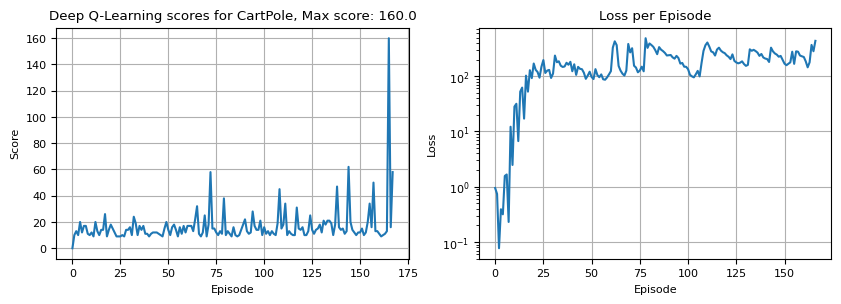

In [16]:
"""## 학습 결과 시각화"""
plt.figure(figsize=(10, 3))

plt.subplot(1, 2, 1)
plt.plot(scores)
plt.title(f'Deep Q-Learning scores for CartPole, Max score: {max(scores)}')
plt.xlabel('Episode')
plt.ylabel('Score')
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(losses)
plt.title('Loss per Episode')
plt.xlabel('Episode')
plt.ylabel('Loss')
plt.semilogy() # Y축을 로그 스케일로
plt.grid()

plt.show()

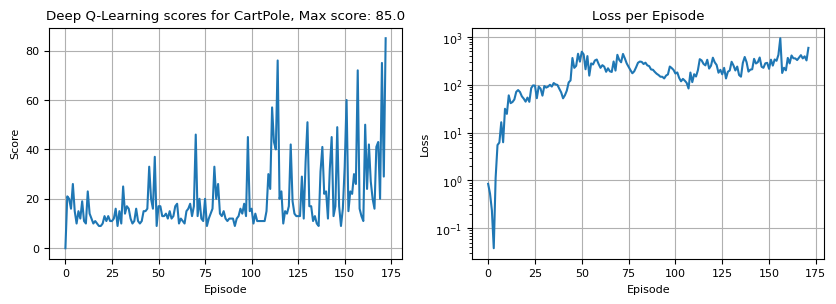

# Evaluation  

In [23]:
## Load Best agent model
agent.load_model(model_path)

모델을 /content/gdrive/MyDrive/Colab Notebooks/models/DRL/dqn_cartpole.pth에서 불러왔습니다.


In [24]:
%%capture
!pip install pyvirtualdisplay
!sudo apt-get update
!sudo apt-get install python-opengl
!sudo apt-get install -f
!sudo apt-get upgrade --fix-missing
!sudo apt-get install xvfb

In [25]:
from render import  show_video, wrap_env, render_as_image ## library 불러오기

In [26]:
from pyvirtualdisplay import Display
display = Display(visible=0, size=(400, 300))
display.start()

In [27]:
env_v = wrap_env(env, path=path, name_prefix="q2")

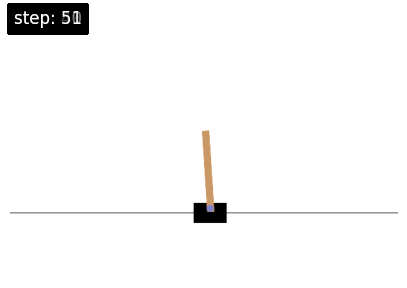

In [28]:
import time
state, _ = env_v.reset()
if isinstance(state, tuple): state = state[0]

agent.epsilon = 0.0
step_cnt = 0
while True:
    render_as_image(env_v,step=step_cnt)
    time.sleep(0.02)
    action = agent.get_action(state.reshape(1,4))
    state, reward, done, info, _ = env_v.step(action)
    if done or step_cnt>50:  break;
    step_cnt += 1
# env_v.close()

In [29]:
show_video(path=path,name_prefix='q2')

/content/gdrive/MyDrive/Colab Notebooks/video/q2-episode-0.mp4


In [ ]:
show_video(path=path,name_prefix='q2')

/content/gdrive/MyDrive/Colab Notebooks/video/q2-episode-0.mp4


# 실습과제  
## 100 episode에서 성능을 최대한 높여보자  
## 어떤 부분을 tuning해 볼 수 있을까?  
### epsilon?, epsilon scheduling?
### Learning rate?, learning rate scheduling?  
### Model 수정?